# 00. Contents

### 01. Importing libraries
### 02. Importing dataframe
### 03. Inspecting the data
### 04. Data wrangling
   #### Changing data types
   #### Splitting up date and time column
   #### Subsetting viral and non-viral data
### 05. Data consistency
### 06. The analysis
   #### Which posts get the highest engagement rate?
   #### Does the number of hashtags correlate with the performance of the post?
   #### What is the relationship between reach and engagement rate?
   #### Does sentiment score affect engagement rate?
   #### What content goes viral?
### 07. The results

# 01. Importing libraries

In [4]:
import pandas as pd
import numpy as np
import os

# 02. Importing dataframe

In [6]:
# Creating a path

path = r'/Users/agne/Documents/Jobs/Portfolio projects/Social Media Analysis/'

In [7]:
# Importing the data

df_soc = pd.read_csv(os.path.join(path, 'social_media_performance.csv'))

# 03. Inspecting the data

In [9]:
# Identifying column names and types
df_soc.dtypes

post_id              int64
platform            object
content_type        object
topic               object
language            object
region              object
post_datetime       object
hashtags            object
sentiment_score    float64
views                int64
likes                int64
comments             int64
shares               int64
engagement_rate    float64
is_viral             int64
dtype: object

In [10]:
# Seeing the examples of data
df_soc.head()

,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,sentiment_score,views,likes,comments,shares,engagement_rate,is_viral
0,1,LinkedIn,article,Technology,UR,BR,2025-04-25 09:47:00,#AI #Innovation #TechTrends #Programming #Codi...,0.76,37781,1202,462,185,0.0490,0
1,2,LinkedIn,poll,Health,FR,JP,2025-10-29 09:44:00,#Fitness #Nutrition #Wellness #Health #MentalH...,0.46,23541,1399,538,215,0.0915,1
2,3,LinkedIn,article,Travel,HI,FR,2025-02-10 14:12:00,#Travel #Journey #Adventure #Tourism #ExploreM...,-0.01,30714,1663,639,255,0.0833,1
3,4,LinkedIn,image,Sports,DE,DE,2025-04-18 22:41:00,#Cricket #Workout #Fitness,0.55,31294,1372,528,211,0.0675,0
4,5,LinkedIn,poll,Business,DE,US,2025-04-28 10:17:00,#Entrepreneur #Leadership #StartupLife,0.70,43129,2234,859,343,0.0797,0


In [11]:
df_soc.tail()

,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,sentiment_score,views,likes,comments,shares,engagement_rate,is_viral
9995,9996,YouTube,video,Food,PT,IN,2025-02-22 19:01:00,#Foodie #Cooking #Food #Recipe #FoodBlog #MustTry,-0.05,430376,39279,15107,6043,0.1404,1
9996,9997,YouTube,video,Technology,DE,US,2025-01-18 20:51:00,#Programming #DataScience #CodingLife #Innovat...,0.61,559223,12513,4812,1925,0.0344,0
9997,9998,YouTube,video,Entertainment,JA,IN,2025-08-12 20:58:00,#Funny #Viral #ShowBiz,0.78,833212,31796,12229,4891,0.0587,0
9998,9999,YouTube,video,Health,EN,DE,2025-04-27 19:04:00,#Wellness #Health #MentalHealth #Fitness #Nutr...,0.49,182707,15690,6034,2413,0.1321,1
9999,10000,YouTube,video,Health,UR,CA,2025-05-16 12:21:00,#Nutrition #MentalHealth #Health,-0.99,937825,33244,12786,5114,0.0545,0


# 04. Data Wrangling

## Changing data types

In [14]:
# Changing post_id type to string
df_soc['post_id'] = df_soc ['post_id'].astype('string')

In [15]:
# Changing post_datetime type to datetime 
df_soc['post_datetime'] = df_soc ['post_datetime'].astype('datetime64[ns]')

In [16]:
# Changing is_viral type to boolean 
df_soc['is_viral'] = df_soc ['is_viral'].astype('bool')

In [17]:
# Checking the result
df_soc.dtypes

post_id            string[python]
platform                   object
content_type               object
topic                      object
language                   object
region                     object
post_datetime      datetime64[ns]
hashtags                   object
sentiment_score           float64
views                       int64
likes                       int64
comments                    int64
shares                      int64
engagement_rate           float64
is_viral                     bool
dtype: object

## Splitting up date and time column

In [19]:
# Splitting up the post_datetime into month, hours, and day of the week
df_soc['hour'] = df_soc['post_datetime'].dt.hour
df_soc['day_of_week'] = df_soc['post_datetime'].dt.day_name()
df_soc['month'] = df_soc['post_datetime'].dt.month_name()

In [20]:
# Reordering the table
df_soc = df_soc[['post_id', 'platform', 'content_type', 'topic', 'language','region', 'post_datetime', 'month', 'day_of_week', 'hour', 'hashtags', 'sentiment_score', 'views', 'likes', 'comments', 'shares', 'engagement_rate', 'is_viral']]

In [21]:
# Checking the result
df_soc.head()

,post_id,platform,content_type,topic,language,region,post_datetime,month,day_of_week,hour,hashtags,sentiment_score,views,likes,comments,shares,engagement_rate,is_viral
0,1,LinkedIn,article,Technology,UR,BR,2025-04-25 09:47:00,April,Friday,9,#AI #Innovation #TechTrends #Programming #Codi...,0.76,37781,1202,462,185,0.0490,False
1,2,LinkedIn,poll,Health,FR,JP,2025-10-29 09:44:00,October,Wednesday,9,#Fitness #Nutrition #Wellness #Health #MentalH...,0.46,23541,1399,538,215,0.0915,True
2,3,LinkedIn,article,Travel,HI,FR,2025-02-10 14:12:00,February,Monday,14,#Travel #Journey #Adventure #Tourism #ExploreM...,-0.01,30714,1663,639,255,0.0833,True
3,4,LinkedIn,image,Sports,DE,DE,2025-04-18 22:41:00,April,Friday,22,#Cricket #Workout #Fitness,0.55,31294,1372,528,211,0.0675,False
4,5,LinkedIn,poll,Business,DE,US,2025-04-28 10:17:00,April,Monday,10,#Entrepreneur #Leadership #StartupLife,0.70,43129,2234,859,343,0.0797,False


## Subsetting viral and non viral data

In [23]:
# Making a subset for the viral data
df_viral = df_soc.loc[df_soc['is_viral'] == True]

In [24]:
df_viral.shape

(5457, 18)

In [25]:
# Making a subset for non viral data
df_non_viral = df_soc.loc[df_soc['is_viral'] == False]

In [26]:
df_non_viral.shape

(4543, 18)

# 05. Data Consistency

In [28]:
# Finding any missing values
df_soc.isnull().sum()

post_id            0
platform           0
content_type       0
topic              0
language           0
region             0
post_datetime      0
month              0
day_of_week        0
hour               0
hashtags           0
sentiment_score    0
views              0
likes              0
comments           0
shares             0
engagement_rate    0
is_viral           0
dtype: int64

There are no missing values in the data set.

In [30]:
# Identifying if there are any duplicates in the dataframe
df_dups=df_soc[df_soc.duplicated()]

In [31]:
print(df_dups)

Empty DataFrame
Columns: [post_id, platform, content_type, topic, language, region, post_datetime, month, day_of_week, hour, hashtags, sentiment_score, views, likes, comments, shares, engagement_rate, is_viral]
Index: []


No duplicates found.

In [33]:
# Checking for outliers
df_soc.describe()

,post_datetime,hour,sentiment_score,views,likes,comments,shares,engagement_rate
count,10000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025-06-30 16:35:54.384000,13.798000,0.440221,212142.158100,15236.87470,5860.139600,2343.759700,0.112667
min,2025-01-01 00:38:00,0.000000,-1.000000,116.000000,3.00000,1.000000,0.000000,0.008300
25%,2025-03-31 17:29:45,9.000000,0.160000,30936.500000,1623.00000,624.000000,249.000000,0.061900
50%,2025-06-30 17:09:30,14.000000,0.560000,78193.000000,5504.00000,2116.500000,846.500000,0.102000
75%,2025-09-30 09:29:00,19.000000,0.780000,343206.750000,21467.25000,8256.250000,3302.500000,0.151925
max,2025-12-31 23:02:00,23.000000,1.000000,999022.000000,116255.00000,44713.000000,17885.000000,0.300000
std,NaN,5.992344,0.452148,254526.880805,20450.03532,7865.396933,3146.163176,0.064301


There are no outliers in the dataframe.

# 06. The Analysis

### Which posts get the highest engagement rate?

In [37]:
# Determine how the engagement rate was calculated in this dataframe.
df_soc['er_check'] = ((df_soc['likes'] + df_soc['comments'] + df_soc['shares']) / df_soc['views'])
print(df_soc[['engagement_rate', 'er_check']].head(10))

   engagement_rate  er_check
0           0.0490  0.048940
1           0.0915  0.091415
2           0.0833  0.083252
3           0.0675  0.067457
4           0.0797  0.079668
5           0.0885  0.088326
6           0.1323  0.132013
7           0.1363  0.135998
8           0.0600  0.059809
9           0.0483  0.048256


In [38]:
# Check which posts types score highest engagement rates
eng_type = df_soc.groupby('content_type')['engagement_rate'].mean().reset_index()
eng_type = eng_type.sort_values('engagement_rate', ascending=False)
print(eng_type)

  content_type  engagement_rate
2         feed         0.152081
5         reel         0.145252
6        story         0.138121
1     carousel         0.116647
3        image         0.116517
0      article         0.114808
7        video         0.087711
4         poll         0.078742


In [39]:
# Import libraries for visualization

import matplotlib.pyplot as plt
import seaborn as sns
import scipy

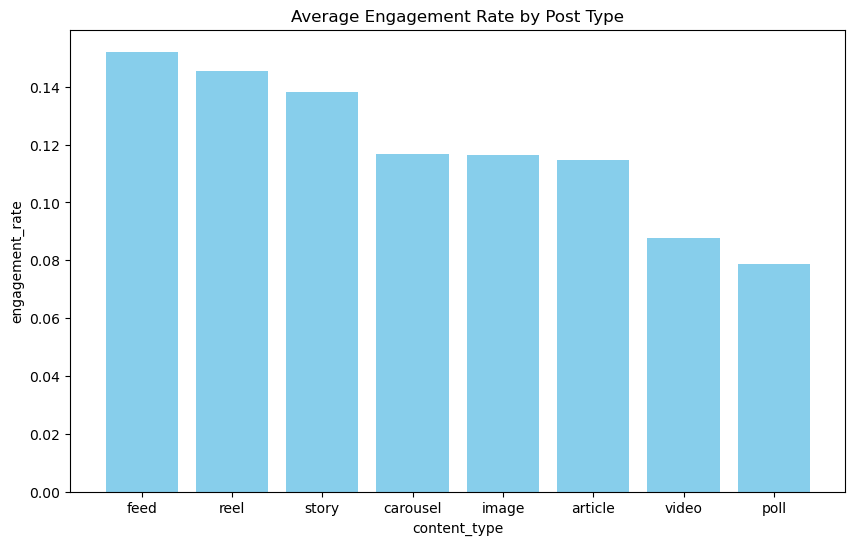

In [40]:
# Creating bar chart for engagement for different post types

plt.figure(figsize=(10, 6))
plt.bar(eng_type['content_type'], eng_type['engagement_rate'], color='skyblue')
plt.title('Average Engagement Rate by Post Type')
plt.xlabel('content_type')
plt.ylabel('engagement_rate')
plt.show()

The best performing type of post is posts on the feed and reels (short videos). The worst are polls.

In [42]:
# Check which platform score highest engagement rates
pf = df_soc.groupby('platform')['engagement_rate'].mean().reset_index()
pf = pf.sort_values('engagement_rate', ascending=False)
print(pf)

    platform  engagement_rate
0  Instagram         0.150352
2     Medium         0.131599
3    YouTube         0.089788
1   LinkedIn         0.078929


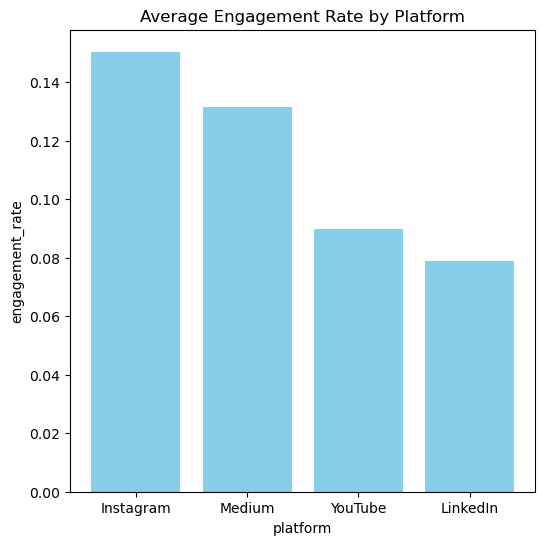

In [43]:
# Creating bar chart for engagement for different platforms

plt.figure(figsize=(6, 6))
plt.bar(pf['platform'], pf['engagement_rate'], color='skyblue')
plt.title('Average Engagement Rate by Platform')
plt.xlabel('platform')
plt.ylabel('engagement_rate')
plt.show()

Instagram is the platform that gets the most engagement. LinkedIn has the least.

In [45]:
# Check which language score highest engagement rates
df_lang = df_soc.groupby('language')['engagement_rate'].mean().reset_index()
df_lang = df_lang.sort_values('engagement_rate', ascending=False)
print(df_lang)

  language  engagement_rate
2       ES         0.115685
7       UR         0.114347
4       HI         0.113025
6       PT         0.112777
1       EN         0.112380
0       DE         0.112045
3       FR         0.110619
5       JA         0.110351


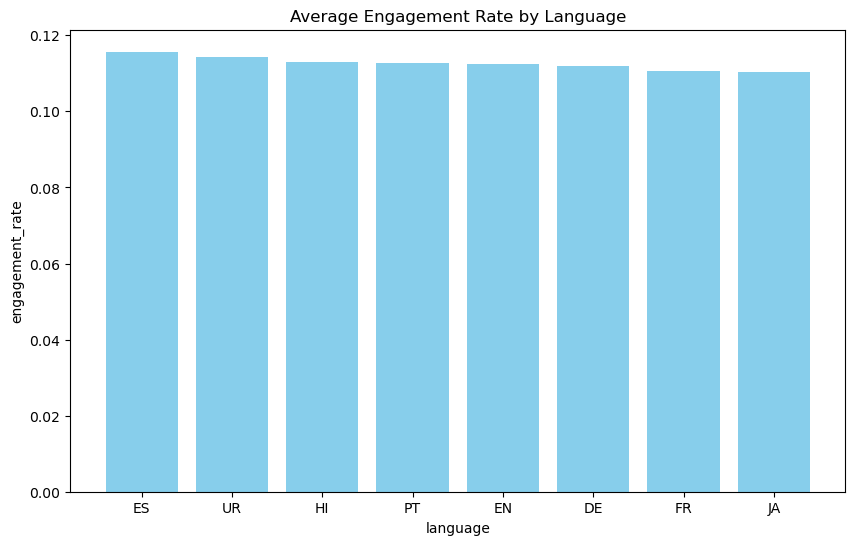

In [46]:
# Creating bar chart for engagement for different languages

plt.figure(figsize=(10, 6))
plt.bar(df_lang['language'], df_lang['engagement_rate'], color='skyblue')
plt.title('Average Engagement Rate by Language')
plt.xlabel('language')
plt.ylabel('engagement_rate')
plt.show()

The engagement rate varies very little between the languages. The difference between the most popular (Spanish) and the least (Japanese) is only 0.005 points. This means that language has very little impact on the performance of a post.

In [48]:
# Check which topic scores highest engagement rates
df_topic = df_soc.groupby('topic')['engagement_rate'].mean().reset_index()
df_topic = df_topic.sort_values('engagement_rate', ascending=False)
print(df_topic)

           topic  engagement_rate
7         Sports         0.115765
2  Entertainment         0.115552
4           Food         0.113020
1      Education         0.112933
0       Business         0.112870
9         Travel         0.112602
3        Fashion         0.111737
8     Technology         0.111713
6      Lifestyle         0.110959
5         Health         0.109711


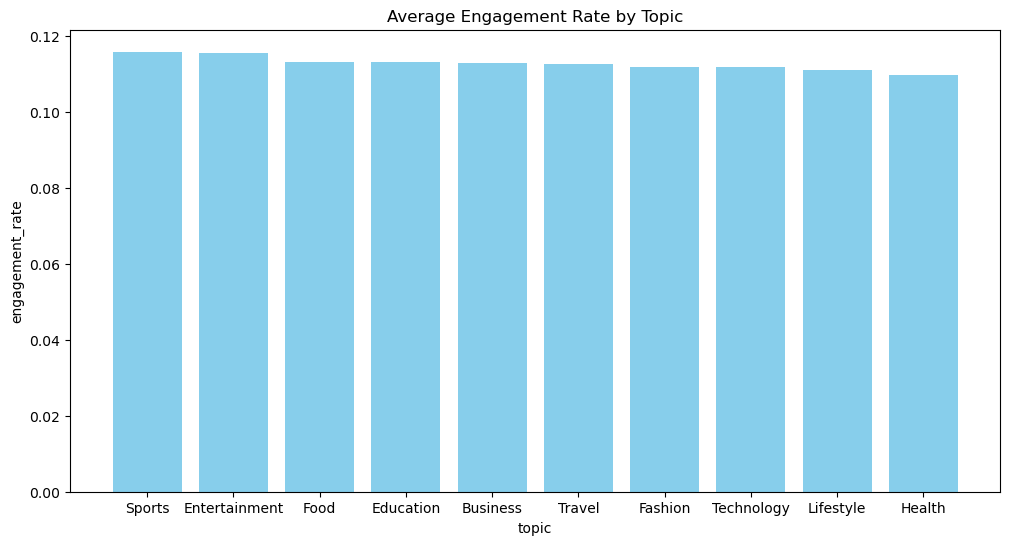

In [49]:
# Creating bar chart for engagement for different topics

plt.figure(figsize=(12, 6))
plt.bar(df_topic['topic'], df_topic['engagement_rate'], color='skyblue')
plt.title('Average Engagement Rate by Topic')
plt.xlabel('topic')
plt.ylabel('engagement_rate')
plt.show()

Again, different topics only slightly impact the engagement. Sports and Entertainment are at the top, with nearly identical scores. The topic of health, on average, is the least interesting. However, the difference across the median is only 0.006 points, which makes the topic of the post not too relevant.

In [51]:
# Check which region scores highest engagement rates
df_region = df_soc.groupby('region')['engagement_rate'].mean().reset_index()
df_region = df_region.sort_values('engagement_rate', ascending=False)
print(df_region)

  region  engagement_rate
1     BR         0.114735
9     US         0.114273
3     DE         0.114109
8     UK         0.114069
0     AU         0.113342
7     MX         0.112820
4     FR         0.112780
2     CA         0.111288
6     JP         0.111083
5     IN         0.108124


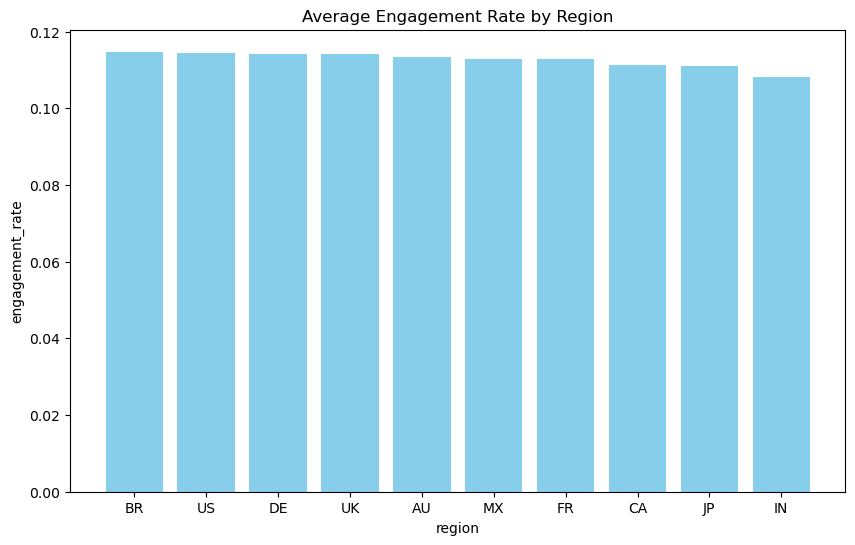

In [52]:
# Creating bar chart for engagement for different regions

plt.figure(figsize=(10, 6))
plt.bar(df_region['region'], df_region['engagement_rate'], color='skyblue')
plt.title('Average Engagement Rate by Region')
plt.xlabel('region')
plt.ylabel('engagement_rate')
plt.show()

The most popular region is Brazil and the least popular is India. However, the difference between the regions is so small, it is barely noticable. So, one can conclude that the region doesn't have a big impact on a post's engagement rate. 

In [57]:
# Check which day of the week scores highest engagement rates

df_dow = df_soc.groupby('day_of_week')['engagement_rate'].mean().reset_index()
df_dow = df_dow.sort_values('engagement_rate', ascending=False)
print(df_dow)

  day_of_week  engagement_rate
0      Friday         0.114609
3      Sunday         0.113679
5     Tuesday         0.113249
4    Thursday         0.113010
2    Saturday         0.112975
6   Wednesday         0.110621
1      Monday         0.110581


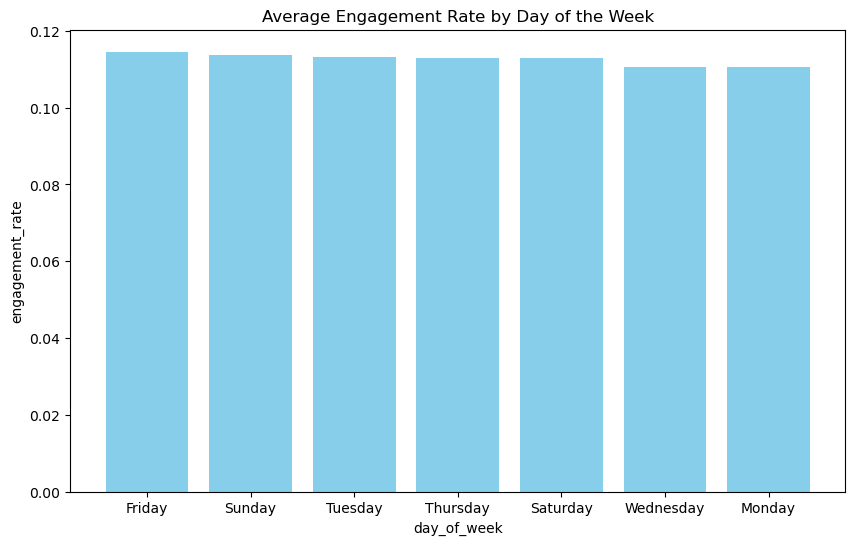

In [58]:
# Creating bar chart for engagement for different regions

plt.figure(figsize=(10, 6))
plt.bar(df_dow['day_of_week'], df_dow['engagement_rate'], color='skyblue')
plt.title('Average Engagement Rate by Day of the Week')
plt.xlabel('day_of_week')
plt.ylabel('engagement_rate')
plt.show()

Looks like Friday is the day when there's the most engagement, and Monday is the slowest day in terms of it. However, the difference is marginal.

In [60]:
# Check which hour of the day score highest engagement rates

df_hod = df_soc.groupby('hour')['engagement_rate'].mean().reset_index()
df_hod = df_hod.sort_values('engagement_rate', ascending=False)
print(df_hod)

    hour  engagement_rate
18    18         0.144195
19    19         0.122587
20    20         0.121416
16    16         0.118649
6      6         0.118314
9      9         0.116094
13    13         0.115481
1      1         0.115125
12    12         0.114983
5      5         0.113684
10    10         0.113607
0      0         0.113511
7      7         0.111553
8      8         0.110711
17    17         0.108923
23    23         0.108608
11    11         0.108196
2      2         0.106913
3      3         0.104119
4      4         0.103386
21    21         0.097489
22    22         0.096557
15    15         0.089949
14    14         0.088577


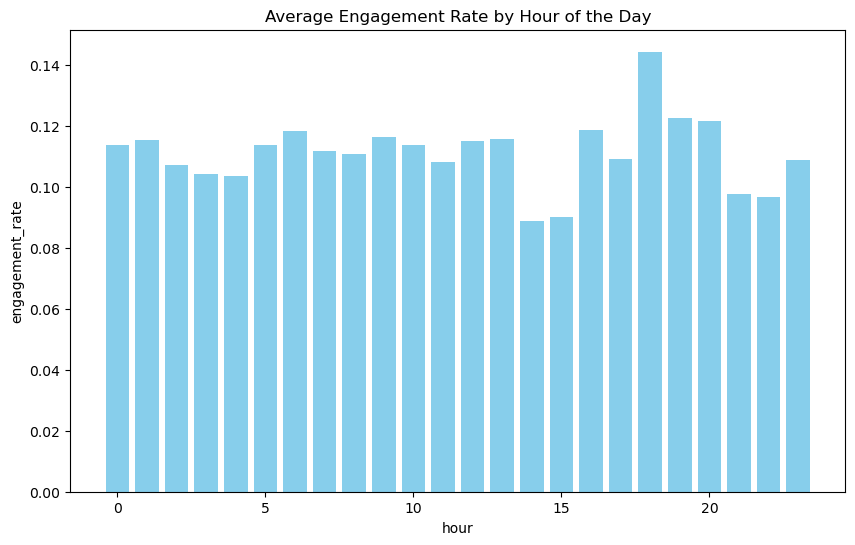

In [61]:
# Creating bar chart for engagement for different hours of the day

plt.figure(figsize=(10, 6))
plt.bar(df_hod['hour'], df_hod['engagement_rate'], color='skyblue')
plt.title('Average Engagement Rate by Hour of the Day')
plt.xlabel('hour')
plt.ylabel('engagement_rate')
plt.show()

Looks like 18:00 or 6 PM is the time when posts get the most engagement. Interestingly, the posts posted right after lunch time, between 14:00 and 15:00, perform even worse than those posted around midnight. Those times are the worst for engagement.

#### Summary

Feed posts and reels posted around 18:00 on Instagram get the most engagement. The language, the region, the day of the week, and even the topic of the post do not impact the engagement in a significant way.

### Does the number of hashtags correlate with the performance of the post?

In [66]:
# Check how to hashtags are stored in the data
print(df_soc['hashtags'].head())
print(type(df_soc['hashtags'][0]))

0    #AI #Innovation #TechTrends #Programming #Codi...
1    #Fitness #Nutrition #Wellness #Health #MentalH...
2    #Travel #Journey #Adventure #Tourism #ExploreM...
3                           #Cricket #Workout #Fitness
4               #Entrepreneur #Leadership #StartupLife
Name: hashtags, dtype: object
<class 'str'>


In [67]:
# Add a column with a hashtag count

df_soc['hashtag_count'] = df_soc['hashtags'].apply(lambda x: len(x.split()))
print(df_soc[['hashtags', 'hashtag_count']].head())

                                            hashtags  hashtag_count
0  #AI #Innovation #TechTrends #Programming #Codi...              7
1  #Fitness #Nutrition #Wellness #Health #MentalH...              6
2  #Travel #Journey #Adventure #Tourism #ExploreM...              6
3                         #Cricket #Workout #Fitness              3
4             #Entrepreneur #Leadership #StartupLife              3


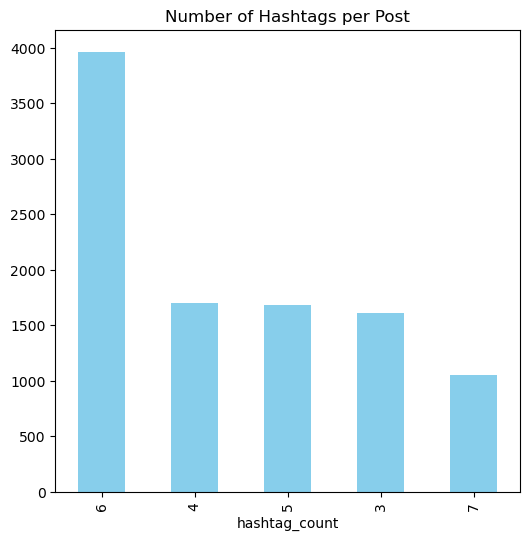

In [68]:
# Creating a bar chart to see how many hashtags are added to posts most frequently
plt.figure(figsize=(6, 6))
df_soc['hashtag_count'].value_counts().plot.bar(color='skyblue')
plt.title('Number of Hashtags per Post')
plt.show()

In [69]:
# Check how the number of hashtags affects the engagement rate

df_hashtag = df_soc.groupby('hashtag_count')['engagement_rate'].mean().reset_index()
df_hashtag = df_hashtag.sort_values('engagement_rate', ascending=False)
print(df_hashtag)

   hashtag_count  engagement_rate
4              7         0.114003
0              3         0.113998
3              6         0.112491
1              4         0.111937
2              5         0.111715


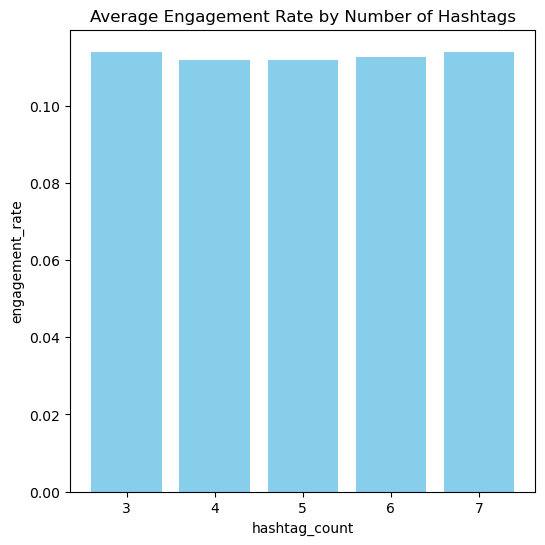

In [70]:
# Creating bar chart for engagement for number of hashtags

plt.figure(figsize=(6, 6))
plt.bar(df_hashtag['hashtag_count'], df_hashtag['engagement_rate'], color='skyblue')
plt.title('Average Engagement Rate by Number of Hashtags')
plt.xlabel('hashtag_count')
plt.ylabel('engagement_rate')
plt.show()

#### Summary

The number of hashtags does not impact the engagement rate in a significant way.

### What is the relationship between reach and engagement rate?

In [74]:
# See if there is a correlation between the views column and the engagement_rate column

correlation = df_soc['views'].corr(df_soc['engagement_rate'])
print(f'Correlation: {correlation}')

Correlation: -0.028038506011097048


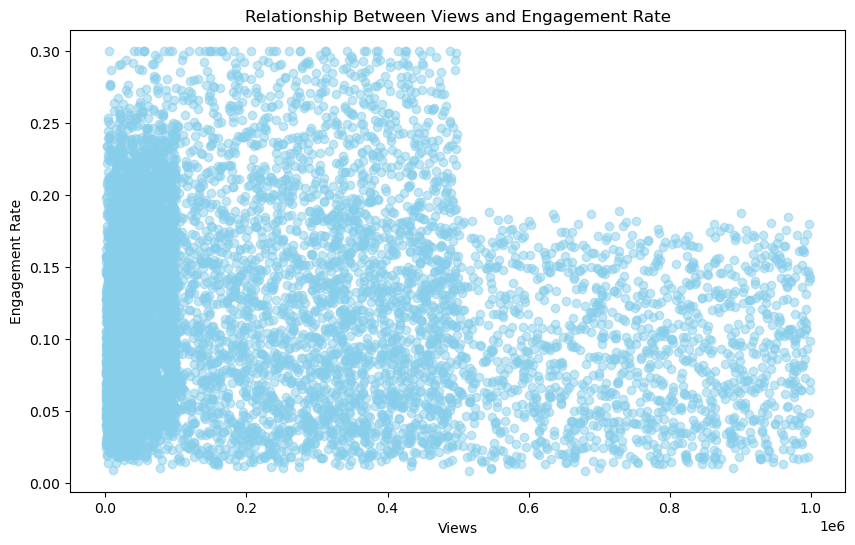

In [75]:
# Visualize the correlation

plt.figure(figsize=(10, 6))
plt.scatter(df_soc['views'], df_soc['engagement_rate'],alpha=0.5, color='skyblue')
plt.title('Relationship Between Views and Engagement Rate')
plt.xlabel('Views')
plt.ylabel('Engagement Rate')
plt.show()

#### Summary

Here I am using view count as a way to determine the reach of a post.
The correlation between views and engagement rate is only very slightly negative, meaning they don't really depend on one another. So, if the post has more views, it doesn't mean that it will have more engagement. In fact, the graph shows the contrary: if the post has more than 500,000 views, the engagement doesn't surpass 20% engagement. The posts under 500,000 views can reach 30% engagement. This means that more niche posts that appeal to a smaller audience can garner more engagement than those that have a mass appeal.

### Does sentiment score affect engagement rate?

In [79]:
# See if there is a correlation between the sentiment score column and the engagement_rate columns

correlation2 = df_soc['sentiment_score'].corr(df_soc['engagement_rate'])
print(f'Correlation: {correlation2}')

Correlation: 0.20552445918839699


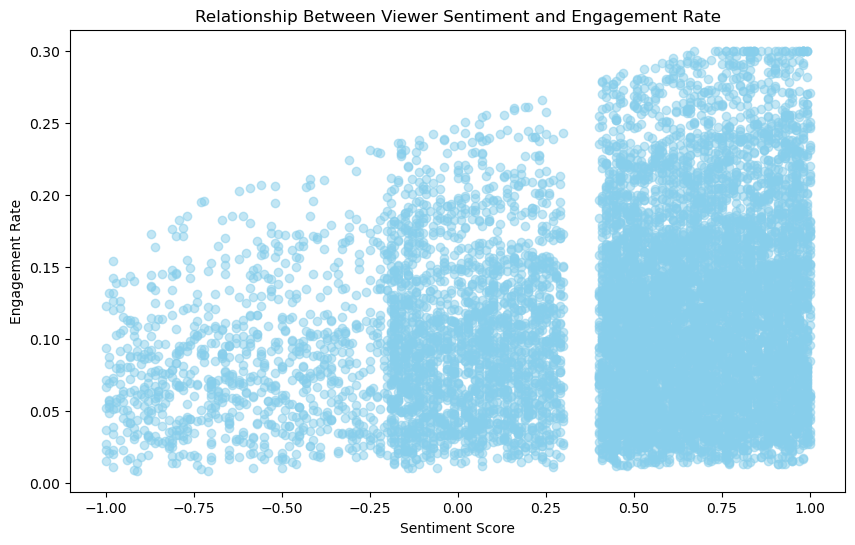

In [80]:
# Visualize the correlation

plt.figure(figsize=(10, 6))
plt.scatter(df_soc['sentiment_score'], df_soc['engagement_rate'],alpha=0.5, color='skyblue')
plt.title('Relationship Between Viewer Sentiment and Engagement Rate')
plt.xlabel('Sentiment Score')
plt.ylabel('Engagement Rate')
plt.show()

#### Summary

There is a weak but notable positive relationship between the sentiment score and engagement rate. This means that the higher the sentiment score is, the more engagement it will receive, and vice versa. 
It's important to note that, when looking at the graph, there is a notable gap in the sentiment score between 0.25 and 0.50 markers. This leads me to believe that the data is compromised in some way. There might have been discrepancies in the data collection or sentiment score calculation. So, this finding should be interpreted with caution.

### What content goes viral?

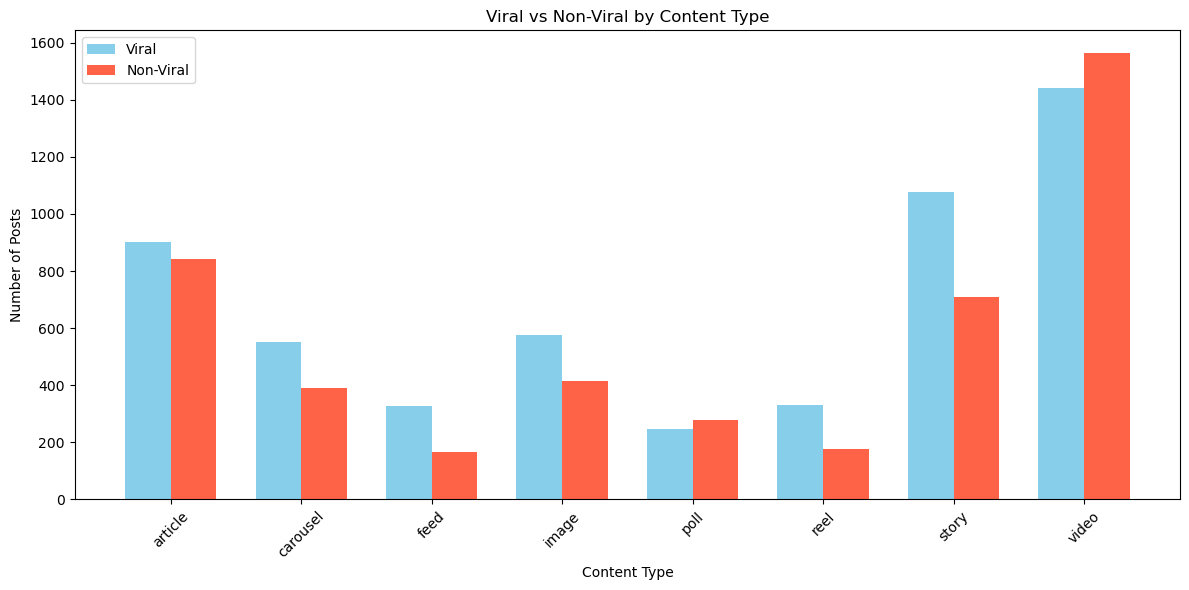

In [84]:
# Plotting bar to see which content type goes viral 

viral_counts = df_viral['content_type'].value_counts().sort_index()
non_viral_counts = df_non_viral['content_type'].value_counts().sort_index()

x = np.arange(len(viral_counts.index))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, viral_counts.values, width, label='Viral', color='skyblue')
plt.bar(x + width/2, non_viral_counts.values, width, label='Non-Viral', color='tomato')
plt.xticks(x, viral_counts.index, rotation=45)
plt.title('Viral vs Non-Viral by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Number of Posts')
plt.legend()
plt.tight_layout()
plt.show()

Video is the most popular form of content, and it goes viral quite often. However, it is more likely not to go viral. On the other hand, stories, images, feed posts, and reels are not as common but are more likely to gain more traction. This means that a good strategy would be to pivot away from focusing on videos and focus more on feed posts (such as images and reels) and do more stories that are more immediate, usually take less effort, and are quite impactful.

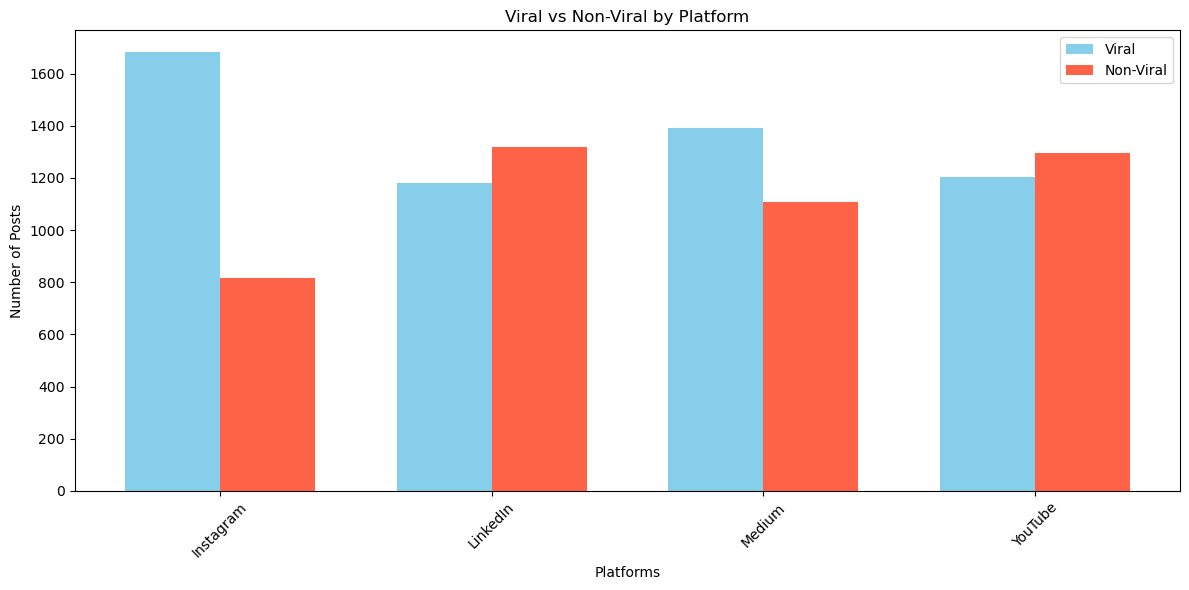

In [86]:
# Plotting bar to see which platform gets more viral posts

viral_counts = df_viral['platform'].value_counts().sort_index()
non_viral_counts = df_non_viral['platform'].value_counts().sort_index()

x = np.arange(len(viral_counts.index))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, viral_counts.values, width, label='Viral', color='skyblue')
plt.bar(x + width/2, non_viral_counts.values, width, label='Non-Viral', color='tomato')
plt.xticks(x, viral_counts.index, rotation=45)
plt.title('Viral vs Non-Viral by Platform')
plt.xlabel('Platforms')
plt.ylabel('Number of Posts')
plt.legend()
plt.tight_layout()
plt.show()

In [87]:
# Add a column for sentiment type
def sentiment_type(score):
    if score >= 0.5:
        return 'Very Positive'
    elif score >= 0.1:
        return 'Positive'
    elif score >= -0.1:
        return 'Neutral'
    elif score >= -0.5:
        return 'Negative'
    else:
        return 'Very Negative'

df_soc['sentiment_type'] = df_soc['sentiment_score'].apply(sentiment_type)


In [88]:
# Remaking the subsets for non-viral and viral data
df_viral = df_soc.loc[df_soc['is_viral'] == True]
df_non_viral = df_soc.loc[df_soc['is_viral'] == False]

In [89]:
df_viral.head()

,post_id,platform,content_type,topic,language,region,post_datetime,month,day_of_week,hour,...,sentiment_score,views,likes,comments,shares,engagement_rate,is_viral,er_check,hashtag_count,sentiment_type
1,2,LinkedIn,poll,Health,FR,JP,2025-10-29 09:44:00,October,Wednesday,9,...,0.46,23541,1399,538,215,0.0915,True,0.091415,6,Positive
2,3,LinkedIn,article,Travel,HI,FR,2025-02-10 14:12:00,February,Monday,14,...,-0.01,30714,1663,639,255,0.0833,True,0.083252,6,Neutral
5,6,LinkedIn,image,Sports,FR,AU,2025-10-03 15:25:00,October,Friday,15,...,0.23,11016,633,243,97,0.0885,True,0.088326,5,Positive
6,7,LinkedIn,carousel,Food,HI,FR,2025-07-15 15:16:00,July,Tuesday,15,...,0.49,1212,104,40,16,0.1323,True,0.132013,6,Positive
7,8,LinkedIn,image,Fashion,ES,AU,2025-02-24 09:40:00,February,Monday,9,...,0.69,8331,737,283,113,0.1363,True,0.135998,6,Very Positive


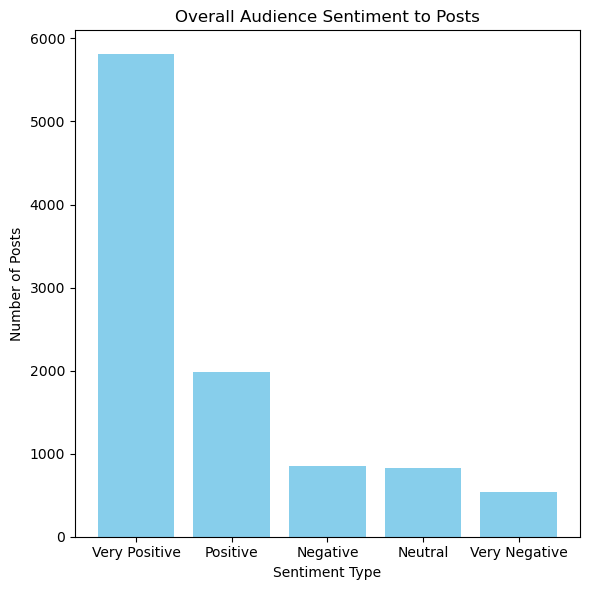

In [90]:
# Plotting the overview of all the sentiment across all the social media posts

sentiment_counts = df_soc['sentiment_type'].value_counts()

plt.figure(figsize=(6, 6))
plt.bar(sentiment_counts.index, sentiment_counts.values, color='skyblue')
plt.title('Overall Audience Sentiment to Posts')
plt.xlabel('Sentiment Type')
plt.ylabel('Number of Posts')
plt.tight_layout()
plt.show()

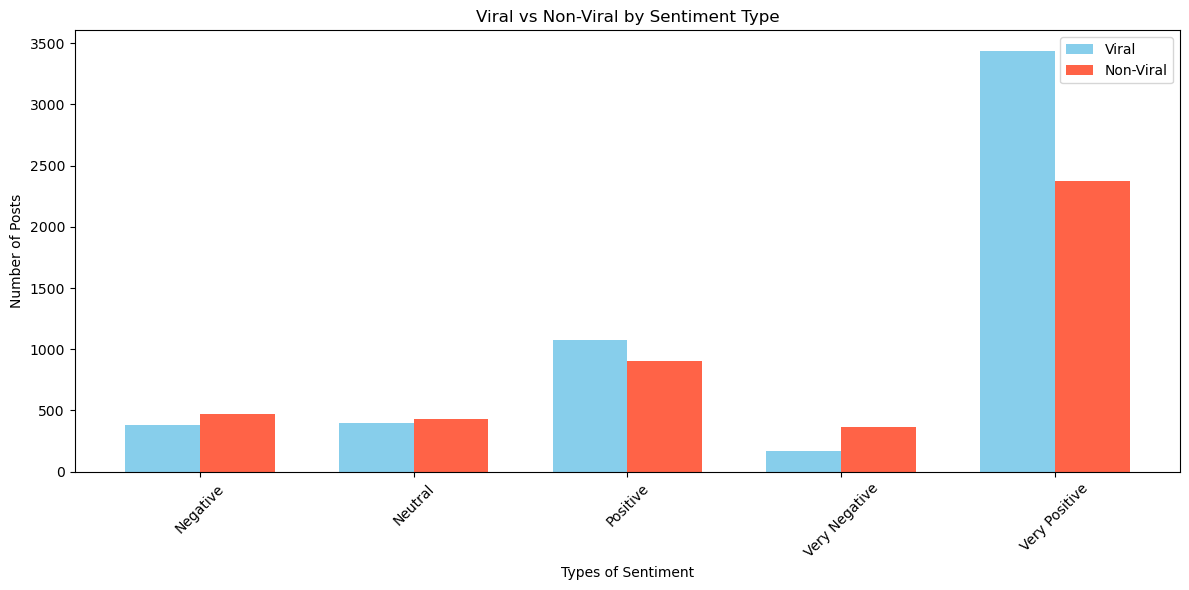

In [91]:
# Plotting bar to see which sentiment type is the more prevelent in viral vs. non-viral posts

viral_sentiment = df_viral['sentiment_type'].value_counts().sort_index()
non_viral_sentiment = df_non_viral['sentiment_type'].value_counts().sort_index()

x = np.arange(len(viral_sentiment.index))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, viral_sentiment.values, width, label='Viral', color='skyblue')
plt.bar(x + width/2, non_viral_sentiment.values, width, label='Non-Viral', color='tomato')
plt.xticks(x, viral_sentiment.index, rotation=45)
plt.title('Viral vs Non-Viral by Sentiment Type')
plt.xlabel('Types of Sentiment')
plt.ylabel('Number of Posts')
plt.legend()
plt.tight_layout()
plt.show()

### Summary

When it comes to viral posts, Instagram delivers the best results, with Medium coming in second place. As for the type of post that succeeds in going viral, stories, images, and reels seem to have the highest chances of doing so. While the most popular type of post overall is video, and there are a lot of successful ones out there, unfortunately, non-viral videos are more common than viral videos, so they are not a safe bet per se. Changing the strategy and focusing on feed posts (such as images and reels) and stories should be the way to go. 

When it comes to audience sentiment, most posts have overall positive comments, with viral posts mostly gaining very positive sentiment scores. This means that posting controversial posts does not really pay off, it doesn't encourage discussion, and this particular audience is not enticed by it. Therefore, if the brand is looking to go viral, they should focus on posts with uplifting, positive messaging and put their efforts into Instagram stories, images, and reels.

# 07. The results

#### The analysis allowed us to see that:
- The best performing type of post is posts on the feed and reels (short videos). The worst are polls.
- Instagram is the platform that gets the most engagement. LinkedIn has the least.
- The language, the region, the day of the week, and even the topic of the post do not impact the engagement in a significant way.
- 18:00 (6:00 PM) is the best time for posting in terms of engagement.
- The number of hashtags does not impact the engagement rate in a significant way.
- If the post has more views, it doesn't mean that it will have more engagement. 
- More niche posts that appeal to a smaller audience can garner more engagement than those that have a mass appeal.
- When it comes to virality, Instagram is the go-to platform.
- Stories, reels, images, and feed posts outperform videos when it comes to going viral.
- Posts with positive sentiments tend to go viral the most.

#### Based on these findings, these are the recommended next steps:

- Focusing on Instagram over other platforms.
- Posting more reels and feed posts instead of longer videos.
- Scheduling posts to come out around 18:00 (6:00 PM).
- Targeting niche audiences instead of looking for mass appeal.
- Crafting uplifting, positive messages instead of controversial ones.